# Model Training & Evaluation
Loads preprocessed data and trains three models in order of complexity.


Structure:

- Loads the preprocessed_data.pkl from the previous notebook
- Logistic Regression — baseline model
- XGBoost — should report better performance
- DistilBERT — should be best performance
- Final comparison — bar chart and ROC curves across all three models side by side


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

sns.set_theme(style='darkgrid')
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Preprocessed Data

In [3]:
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_tfidf_train    = data['X_tfidf_train']
X_tfidf_test     = data['X_tfidf_test']
X_combined_train = data['X_combined_train']
X_combined_test  = data['X_combined_test']
X_text_train     = data['X_text_train']
X_text_test      = data['X_text_test']
y_train          = data['y_train']
y_test           = data['y_test']

print('Data loaded ✅')
print(f'Train: {len(y_train):,} | Test: {len(y_test):,}')

Data loaded ✅
Train: 50,496 | Test: 12,625


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Helper: Evaluation Function
Reused for every model to keep results consistent.

In [4]:
results = {}  # stores all model results for final comparison

def evaluate(name, y_true, y_pred, y_prob):
    metrics = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1'       : f1_score(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob)
    }
    results[name] = metrics

    print(f'\n--- {name} ---')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return metrics

---
## 3. Model 1 — Baseline: TF-IDF + Logistic Regression
> Fast, interpretable, strong baseline. Uses TF-IDF vectors only.

Training Logistic Regression...

--- Logistic Regression ---
  Accuracy: 0.9552
  Precision: 0.9536
  Recall: 0.9463
  F1: 0.9500
  ROC-AUC: 0.9918


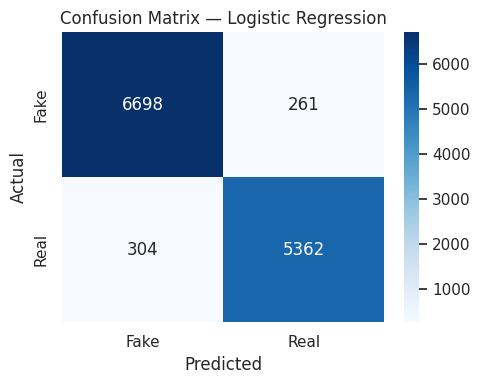

{'Accuracy': 0.9552475247524752,
 'Precision': 0.9535834963542593,
 'Recall': 0.9463466290151783,
 'F1': 0.9499512800070865,
 'ROC-AUC': np.float64(0.9917510645657053)}

In [5]:
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1)
lr.fit(X_tfidf_train, y_train)

lr_pred = lr.predict(X_tfidf_test)
lr_prob = lr.predict_proba(X_tfidf_test)[:, 1]

evaluate('Logistic Regression', y_test, lr_pred, lr_prob)

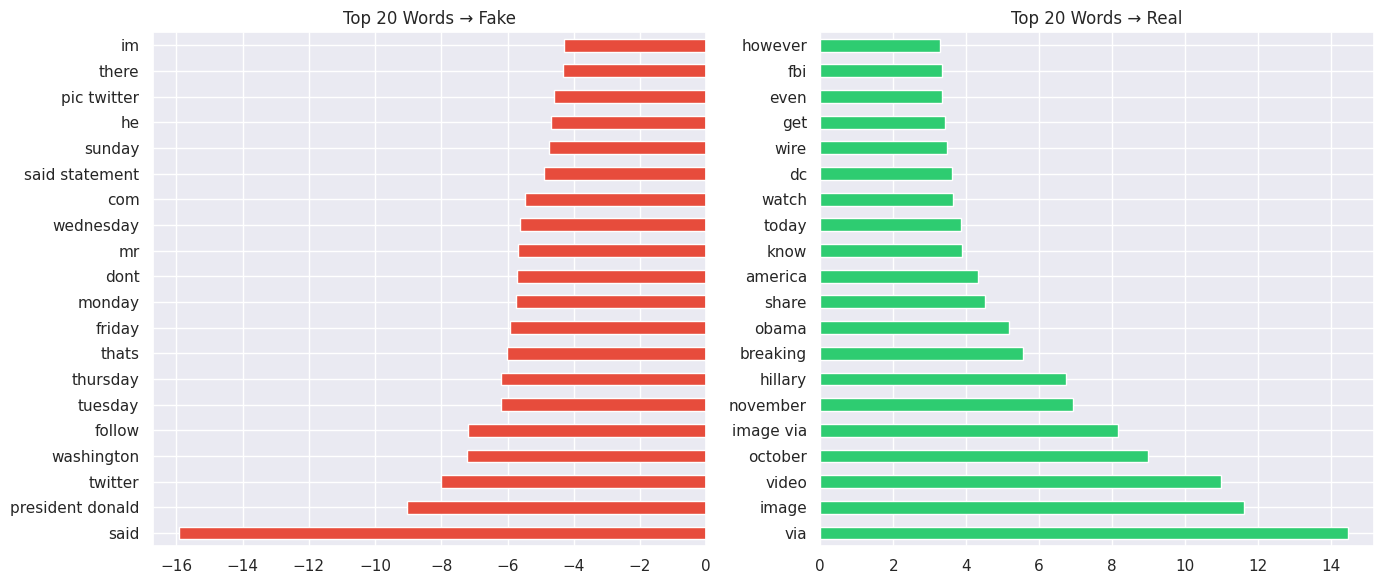

In [6]:
# Top predictive words for each class
tfidf_vocab = data['tfidf'].get_feature_names_out()
coefs = lr.coef_[0]

top_fake = pd.Series(coefs, index=tfidf_vocab).nsmallest(20)
top_real = pd.Series(coefs, index=tfidf_vocab).nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_fake.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 20 Words → Fake')
top_real.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 20 Words → Real')
plt.tight_layout()
plt.show()

---
## 4. Model 2 — XGBoost + Engineered Features
> Combines TF-IDF with handcrafted features (word count, caps ratio, etc.) from preprocessing.

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:27:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
  Accuracy: 0.9610
  Precision: 0.9566
  Recall: 0.9566
  F1: 0.9566
  ROC-AUC: 0.9933


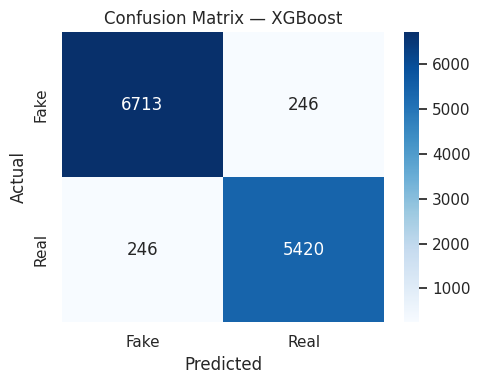

{'Accuracy': 0.961029702970297,
 'Precision': 0.9565831274267561,
 'Recall': 0.9565831274267561,
 'F1': 0.9565831274267561,
 'ROC-AUC': np.float64(0.9933147845377648)}

In [7]:
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_combined_train, y_train)

xgb_pred = xgb.predict(X_combined_test)
xgb_prob = xgb.predict_proba(X_combined_test)[:, 1]

evaluate('XGBoost', y_test, xgb_pred, xgb_prob)

---
## 5. Model 3 — Fine-tuned DistilBERT


In [8]:
# Install if needed
# !pip install transformers torch datasets

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [10]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = NewsDataset(X_text_train, y_train.tolist(), tokenizer)
test_dataset  = NewsDataset(X_text_test,  y_test.tolist(),  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 3156 | Test batches: 395


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(device)

EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader),
    num_training_steps=EPOCHS * len(train_loader)
)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f}')

print('Training complete ✅')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 — Loss: 0.2494
Epoch 2/3 — Loss: 0.0798
Epoch 3/3 — Loss: 0.0274
Training complete ✅



--- DistilBERT ---
  Accuracy: 0.9838
  Precision: 0.9846
  Recall: 0.9792
  F1: 0.9819
  ROC-AUC: 0.9984


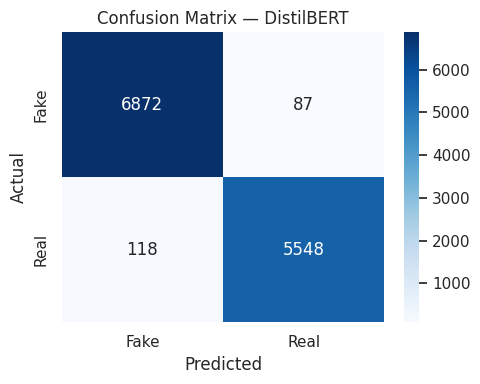

{'Accuracy': 0.9837623762376237,
 'Precision': 0.9845607808340727,
 'Recall': 0.9791740204729968,
 'F1': 0.9818600123882842,
 'ROC-AUC': np.float64(0.9984368126214725)}

In [12]:
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds          = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)

evaluate('DistilBERT', y_test, all_preds, all_probs)

In [13]:
# Save the model
model.save_pretrained('./distilbert_model')
tokenizer.save_pretrained('./distilbert_model')
print('DistilBERT model saved to ./distilbert_model ✅')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved to ./distilbert_model ✅


---
## 6. Final Model Comparison

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9552     0.9536  0.9463  0.9500   0.9918
XGBoost                0.9610     0.9566  0.9566  0.9566   0.9933
DistilBERT             0.9838     0.9846  0.9792  0.9819   0.9984


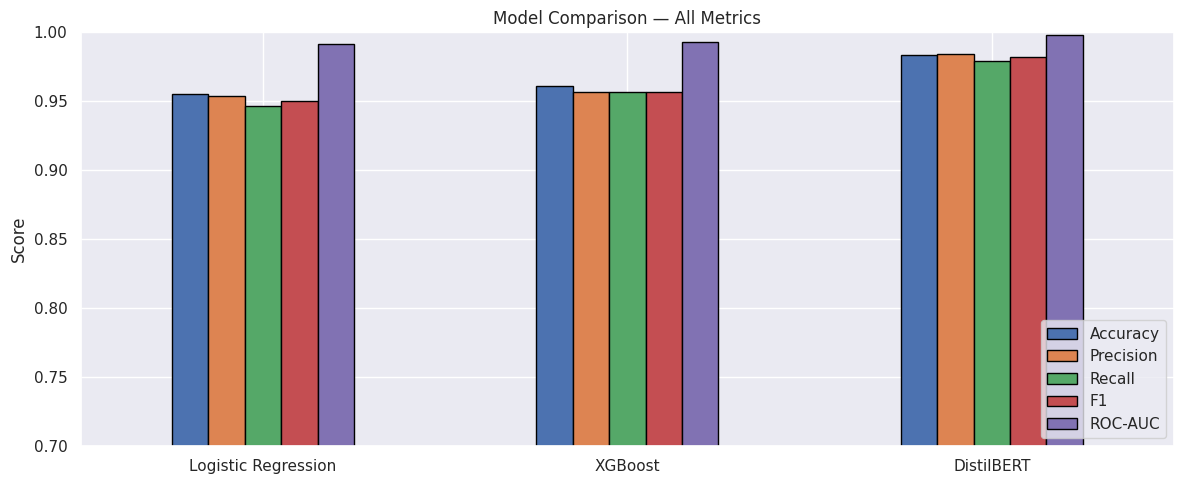

In [14]:
comparison = pd.DataFrame(results).T.round(4)
print(comparison.to_string())

comparison.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

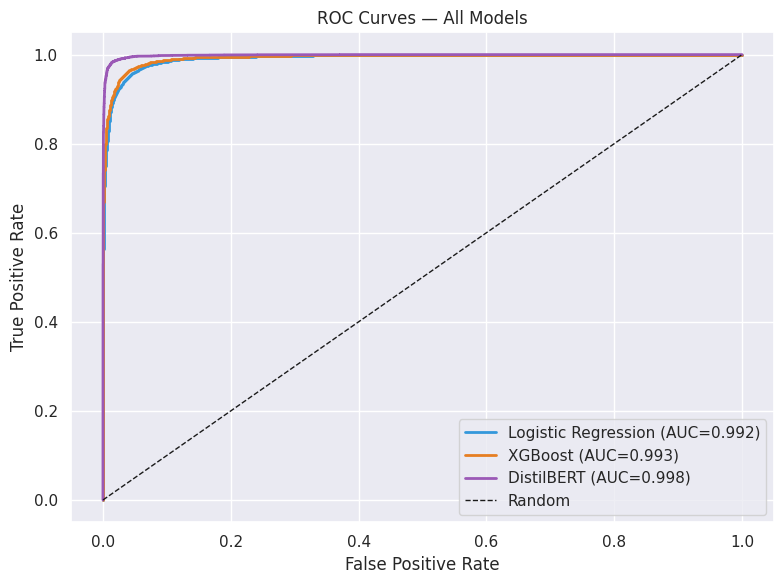

In [15]:
# ROC curves for all models
plt.figure(figsize=(8, 6))

for name, y_prob, color in zip(
    ['Logistic Regression', 'XGBoost', 'DistilBERT'],
    [lr_prob, xgb_prob, all_probs],
    ['#3498db', '#e67e22', '#9b59b6']
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

# DistilBERT had the best performance in every category when classifying!